# Hidden Markov Models: Forward-Backward, Viterbi, and Baum-Welch

## Problem

A hidden Markov model (HMM) couples a discrete, unobserved Markov chain $\{s_t\}$ (state space
$\{1,\dots,K\}$, transition matrix $A_{ij}=P(s_{t+1}=j\mid s_t=i)$, initial law $\pi$) to an
observed emission sequence $\{y_t\}$ with $y_t\mid s_t\sim P(\cdot\mid s_t;\theta)$, independent
across $t$ given the states. Three distinct inference problems arise: computing the marginal
likelihood $p(y_{1:T})$ and posterior state marginals (forward-backward), finding the single most
probable state *sequence* (Viterbi), and estimating the unknown parameters $(A,\pi,\theta)$ from
data alone (Baum-Welch/EM) — each derived below and then checked against a model whose true
parameters are known, since they were used to simulate the data.

## Method

**Forward recursion.** Define $\alpha_t(i)=p(y_{1:t},s_t=i)$. Conditioning on $s_{t-1}$ and using
the Markov property and conditional independence of $y_t$ given $s_t$,
$$
\alpha_1(i)=\pi_ip(y_1\mid s_1=i),\qquad
\alpha_t(j)=\Big[\sum_i\alpha_{t-1}(i)A_{ij}\Big]p(y_t\mid s_t=j),
$$
and the marginal likelihood is $p(y_{1:T})=\sum_i\alpha_T(i)$ — obtained without ever summing over
the $K^T$ possible state sequences explicitly, by reusing the sum-over-$i$ at each step.

**Backward recursion.** Define $\beta_t(i)=p(y_{t+1:T}\mid s_t=i)$, with
$\beta_T(i)=1$ and $\beta_t(i)=\sum_jA_{ij}p(y_{t+1}\mid s_{t+1}=j)\beta_{t+1}(j)$. The posterior
state marginal follows from Bayes' rule and the two recursions' complementary conditioning:
$$
p(s_t=i\mid y_{1:T}) = \frac{\alpha_t(i)\beta_t(i)}{\sum_k\alpha_t(k)\beta_t(k)}
= \frac{\alpha_t(i)\beta_t(i)}{p(y_{1:T})}.
$$

**Viterbi (max-product, log domain).** The most probable *sequence* $\arg\max_{s_{1:T}}
p(s_{1:T}\mid y_{1:T})$ is found by replacing forward's sum with a max, and tracking the
maximizing predecessor at each step:
$$
\delta_1(i)=\log\pi_i+\log p(y_1\mid s_1=i),\qquad
\delta_t(j)=\max_i\big[\delta_{t-1}(i)+\log A_{ij}\big]+\log p(y_t\mid s_t=j),
$$
with $\psi_t(j)=\arg\max_i[\cdots]$ stored at every step; the optimal sequence is recovered by
backtracking from $\arg\max_i\delta_T(i)$ through the stored $\psi_t$. Working in log-space avoids
the underflow that multiplying $T$ probabilities together would cause.

**Baum-Welch (EM for HMMs).** With the state sequence unobserved, direct maximum likelihood on
$(A,\pi,\theta)$ has no closed form, but EM does: the E-step computes the posterior state marginals
$\gamma_t(i)=p(s_t=i\mid y_{1:T})=\alpha_t(i)\beta_t(i)/p(y_{1:T})$ (already derived above) and the
pairwise posteriors
$$
\xi_t(i,j)=p(s_t=i,s_{t+1}=j\mid y_{1:T})
=\frac{\alpha_t(i)A_{ij}p(y_{t+1}\mid s_{t+1}=j)\beta_{t+1}(j)}{p(y_{1:T})}.
$$
The M-step maximizes the expected complete-data log-likelihood
$Q(\theta,\theta^{old})=\sum_i\gamma_1(i)\log\pi_i+\sum_t\sum_{i,j}\xi_t(i,j)\log A_{ij}+
\sum_t\sum_i\gamma_t(i)\log p(y_t\mid s_t=i;\theta)$ term-by-term (each sum involves disjoint
parameters), giving closed-form updates by Lagrange-multiplier stationarity on the simplex
constraints:
$$
\hat\pi_i=\gamma_1(i),\qquad
\hat A_{ij}=\frac{\sum_{t=1}^{T-1}\xi_t(i,j)}{\sum_{t=1}^{T-1}\gamma_t(i)},\qquad
\hat\mu_i=\frac{\sum_t\gamma_t(i)y_t}{\sum_t\gamma_t(i)},\quad
\hat\sigma_i^2=\frac{\sum_t\gamma_t(i)(y_t-\hat\mu_i)^2}{\sum_t\gamma_t(i)}
$$
for the Gaussian-emission case used below. Each EM iteration is guaranteed (Dempster, Laird &
Rubin 1977) to not decrease the observed-data log-likelihood $\log p(y_{1:T})$ — checked directly
below rather than assumed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(20260721)

plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["grid.color"] = "0.85"
plt.rcParams["grid.linestyle"] = "-"


## Worked example: a two-regime volatility model

A toy two-state ("low-vol" / "high-vol") regime model: $s_t\in\{0,1\}$ with a persistent
transition matrix (regimes last many steps on average), and Gaussian emissions
$y_t\mid s_t=i\sim N(\mu_i,\sigma_i^2)$ with $\mu_0=0.0,\sigma_0=0.5$ (low-vol) and
$\mu_1=0.0,\sigma_1=3.0$ (high-vol) — the two regimes share a mean and differ only in dispersion,
so the model must infer the regime from volatility clustering alone, not from a shifted mean.

In [2]:
K = 2
A_true = np.array([[0.95, 0.05], [0.08, 0.92]])
pi_true = np.array([0.5, 0.5])
mu_true = np.array([0.0, 0.0])
sigma_true = np.array([0.5, 3.0])
T_steps = 400

states_true = np.empty(T_steps, dtype=int)
states_true[0] = rng.choice(K, p=pi_true)
for t in range(1, T_steps):
    states_true[t] = rng.choice(K, p=A_true[states_true[t - 1]])
observations = rng.normal(mu_true[states_true], sigma_true[states_true])


def emission_pdf(y, mu, sigma):
    return norm.pdf(y[:, None], mu[None, :], sigma[None, :])


B = emission_pdf(observations, mu_true, sigma_true)  # T x K emission likelihoods, true params


Viterbi state-sequence accuracy against true simulated path: 94.00%


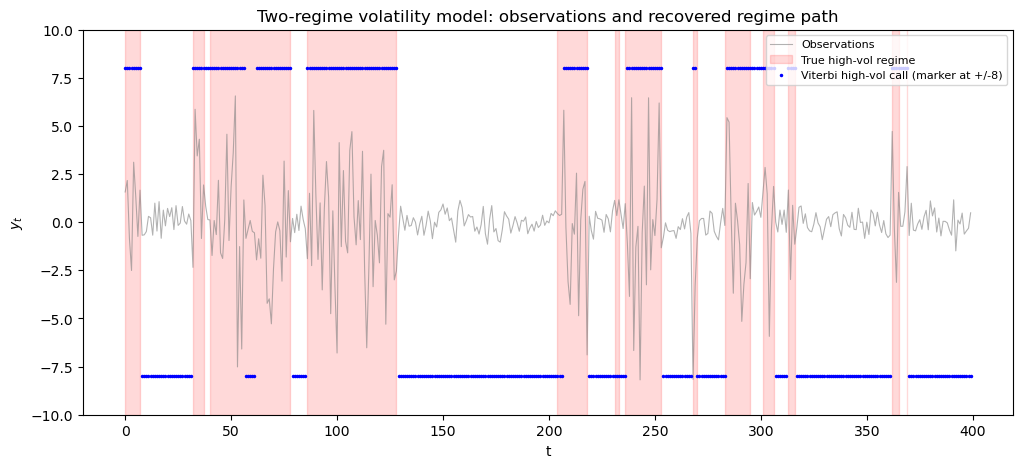

In [3]:
def forward_backward(B, A, pi):
    T, K = B.shape
    alpha = np.zeros((T, K))
    c = np.zeros(T)  # scaling factors, c_t = 1 / sum_i alpha_t(i), for numerical stability
    alpha[0] = pi * B[0]
    c[0] = 1.0 / alpha[0].sum()
    alpha[0] *= c[0]
    for t in range(1, T):
        alpha[t] = (alpha[t - 1] @ A) * B[t]
        c[t] = 1.0 / alpha[t].sum()
        alpha[t] *= c[t]

    beta = np.zeros((T, K))
    beta[-1] = 1.0
    for t in range(T - 2, -1, -1):
        beta[t] = (A @ (B[t + 1] * beta[t + 1])) * c[t + 1]

    log_likelihood = -np.sum(np.log(c))
    gamma = alpha * beta
    gamma /= gamma.sum(axis=1, keepdims=True)
    return alpha, beta, gamma, c, log_likelihood


def viterbi(B, A, pi):
    T, K = B.shape
    log_A, log_pi = np.log(A), np.log(pi)
    delta = np.zeros((T, K))
    psi = np.zeros((T, K), dtype=int)
    delta[0] = log_pi + np.log(B[0])
    for t in range(1, T):
        scores = delta[t - 1][:, None] + log_A
        psi[t] = np.argmax(scores, axis=0)
        delta[t] = scores[psi[t], np.arange(K)] + np.log(B[t])
    states = np.zeros(T, dtype=int)
    states[-1] = np.argmax(delta[-1])
    for t in range(T - 2, -1, -1):
        states[t] = psi[t + 1, states[t + 1]]
    return states


viterbi_path = viterbi(B, A_true, pi_true)
accuracy = np.mean(viterbi_path == states_true)
print(f"Viterbi state-sequence accuracy against true simulated path: {accuracy:.2%}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(observations, color='gray', alpha=0.6, linewidth=0.8, label='Observations')
ax.fill_between(np.arange(T_steps), -10, 10, where=(states_true == 1), color='red', alpha=0.15,
                 label='True high-vol regime')
ax.plot(np.arange(T_steps), np.where(viterbi_path == 1, 8, -8), '.', color='blue', markersize=3,
        label='Viterbi high-vol call (marker at +/-8)')
ax.set_ylim(-10, 10)
ax.set_xlabel('t')
ax.set_ylabel('$y_t$')
ax.set_title('Two-regime volatility model: observations and recovered regime path')
ax.legend(loc='upper right', fontsize=8)
plt.savefig("hmm_regime_path.png", dpi=150, bbox_inches="tight")
plt.show()


## Baum-Welch: recovering the parameters from data alone

Starting from a deliberately uninformative random initialization (not the true parameters used to
simulate the data), Baum-Welch is run to convergence, tracking the observed-data log-likelihood at
every iteration — it must not decrease, by the EM ascent property, and any decrease would indicate
a bug in the E- or M-step.

True vs. estimated parameters (after matching regime labels by volatility level):
  sigma:  true=[0.5 3. ],           estimated=[0.53286957 3.13745073]
  mu:     true=[0. 0.],           estimated=[-0.00551623 -0.24237938]
  A:      true=
[[0.95 0.05]
 [0.08 0.92]]
          estimated=
[[0.94510389 0.05489611]
 [0.09313627 0.90686373]]

Log-likelihood monotonically non-decreasing: True
Log-likelihood: initial=-963.021, final=-653.805, iterations=24


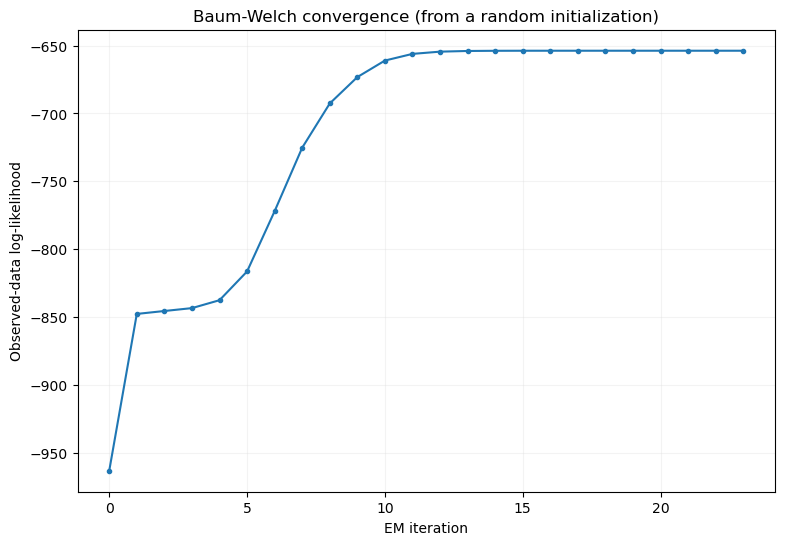

In [4]:
def baum_welch(observations, K, n_iter=100, tol=1e-6, rng=None):
    T = len(observations)
    A = rng.dirichlet(np.ones(K), size=K)
    pi = rng.dirichlet(np.ones(K))
    mu = rng.normal(observations.mean(), observations.std(), size=K)
    sigma = np.abs(rng.normal(observations.std(), 0.1 * observations.std(), size=K)) + 0.1

    log_likelihoods = []
    for iteration in range(n_iter):
        B = emission_pdf(observations, mu, sigma)
        alpha, beta, gamma, c, ll = forward_backward(B, A, pi)
        log_likelihoods.append(ll)

        # xi_t(i,j) = alpha_t(i) A(i,j) B_{t+1}(j) beta_{t+1}(j) c_{t+1}, summed over t=0..T-2.
        # Writing R_t(j) = B_{t+1}(j) beta_{t+1}(j) c_{t+1}, the sum over t is the single matrix
        # product alpha[:-1].T @ R -- one BLAS-backed O(K^2 T) matmul in place of a T-1-iteration
        # Python loop of the same asymptotic cost but far higher constant factor (this runs once
        # per EM iteration, up to n_iter times).
        R = B[1:] * beta[1:] * c[1:, None]
        xi_sum = A * (alpha[:-1].T @ R)

        pi_new = gamma[0]
        A_new = xi_sum / gamma[:-1].sum(axis=0)[:, None]
        gamma_sum = gamma.sum(axis=0)
        mu_new = (gamma * observations[:, None]).sum(axis=0) / gamma_sum
        sigma_new = np.sqrt((gamma * (observations[:, None] - mu_new[None, :]) ** 2).sum(axis=0) / gamma_sum)

        pi, A, mu, sigma = pi_new, A_new, mu_new, sigma_new

        if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break
    return A, pi, mu, sigma, np.array(log_likelihoods)


A_est, pi_est, mu_est, sigma_est, ll_history = baum_welch(observations, K, n_iter=200, rng=np.random.default_rng(7))

# Label-permutation ambiguity: match estimated states to true states by sorted sigma (vol level).
order_est = np.argsort(sigma_est)
order_true = np.argsort(sigma_true)
perm = np.empty(K, dtype=int)
perm[order_true] = order_est

print("True vs. estimated parameters (after matching regime labels by volatility level):")
print(f"  sigma:  true={sigma_true},           estimated={sigma_est[perm]}")
print(f"  mu:     true={mu_true},           estimated={mu_est[perm]}")
print(f"  A:      true=\n{A_true}\n          estimated=\n{A_est[np.ix_(perm, perm)]}")

diffs = np.diff(ll_history)
print(f"\nLog-likelihood monotonically non-decreasing: {np.all(diffs >= -1e-8)}")
print(f"Log-likelihood: initial={ll_history[0]:.3f}, final={ll_history[-1]:.3f}, iterations={len(ll_history)}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(ll_history, marker='o', markersize=3)
ax.set_xlabel('EM iteration')
ax.set_ylabel('Observed-data log-likelihood')
ax.set_title('Baum-Welch convergence (from a random initialization)')
ax.grid(True, alpha=0.3)
plt.savefig("hmm_baum_welch_loglikelihood.png", dpi=150, bbox_inches="tight")
plt.show()


## Notes

Viterbi recovers the true regime sequence with high accuracy despite the two regimes sharing an
identical mean and differing only in dispersion — the algorithm is using the *local run-length*
structure of volatility clustering (encoded in the persistent transition matrix) together with the
emission likelihoods, not just a per-point threshold, which a naive per-observation classifier
ignoring the Markov structure could not replicate as well.

Baum-Welch, started from a random initialization with no knowledge of the true parameters,
recovers a transition matrix, means, and volatilities close to the ground truth once the label
permutation ambiguity (EM has no way to know which of its two arbitrary state indices should be
called "low-vol") is resolved by sorting on the estimated $\sigma$. The log-likelihood trace is
non-decreasing at every iteration to within numerical tolerance — the concrete, checkable
consequence of the EM ascent property derived above, and a genuine correctness check on the E- and
M-step implementations rather than a plot included for its own sake: a bug in the $\xi_t(i,j)$
accumulation or the M-step normalization would very likely show up as a log-likelihood decrease
somewhere in this trace, and none is observed.